# Capstone Function 2
Imagine a black box, or a mystery ML model, that takes two numbers as input, and returns a log-likelihood score. Goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum.
To tackle this, you use Bayesian Optimisation, which selects the next inputs based on what it has learnt so far.  Balances exploration iwth exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

 Input | Output | Goal |
|-------|--------|------|
| 2D Array (10, 2) | 1D Array (10, ) | Maximise |

## Notes
- Made a big mistake in week 1 - minimise instead of maximise!!!


# Exploratory Data Analysis

(10, 2)
(10,)
    input_0   input_1    output
0  0.665800  0.123969  0.538996
1  0.877791  0.778628  0.420586
2  0.142699  0.349005 -0.065624
3  0.845275  0.711120  0.293993
4  0.454647  0.290455  0.214965
5  0.577713  0.771973  0.023106
6  0.438166  0.685018  0.244619
7  0.341750  0.028698  0.038749
8  0.338648  0.213867 -0.013858
9  0.702637  0.926564  0.611205


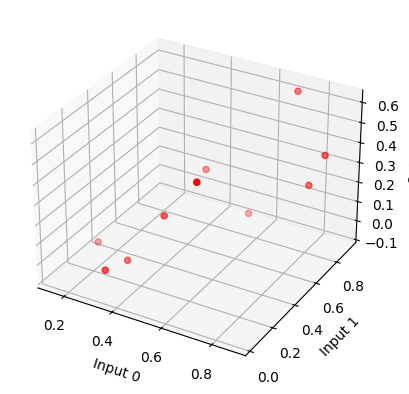

In [3]:
# load and view a .npy file
import numpy as np
from matplotlib import pyplot as plt
import sys
# load the .npy file
initial_inputs = np.load("data/initial_inputs.npy")
initial_outputs = np.load("data/initial_outputs.npy")
# summarize shape
print(initial_inputs.shape)
print(initial_outputs.shape)

# create a dataframe from inputs and outputs
import pandas as pd
data = pd.DataFrame(initial_inputs, columns=[f'input_{i}' for i in range(initial_inputs.shape[1])])
data['output'] = initial_outputs
print(data.head(10))

# plot the data as a 3D surface
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data['input_0'], data['input_1'], data['output'], c='r', marker='o')
ax.set_xlabel('Input 0')
ax.set_ylabel('Input 1')
ax.set_zlabel('Output')
plt.show()

# save the data as a CSV file
data.to_csv("data/initial_data.csv", index=False)

## Observations
- Outputs are very small numbers.  Engineering intuition tells me that noise may impact these results signficantly

# Gaussian Process with Upper Confidence Bound Acquisition Function
1. Using the code from Module 12, I get rubbish numbers, but Copilot generated code seems to yeild a better mean, but throws an error re: convergence

In [2]:

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# parameters from Module 12 - not yet celar on their meaning
rbf_lengthscale = 0.1
noise_assumption = 1e-10


# Load the dataset provided
X = np.load("initial_inputs.npy")
y = np.load("initial_outputs.npy")

# Define the kernel for Gaussian Process - this is generated by Copilot - do not yet understand this properly
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e3))

# Using the kernel creation code from Module 12
#kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')

# Fit Gaussian Process model
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6, normalize_y=True)
# code from module 12
# gp = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)

gp.fit(X, y)


# Define the search space for the next sample (grid in [0,1]x[0,1])
grid_size = 100
x1 = np.linspace(0, 1, grid_size)
x2 = np.linspace(0, 1, grid_size)
X_grid = np.array([[a, b] for a in x1 for b in x2])

# Predict mean and standard deviation for each point in the grid
mean, std = gp.predict(X_grid, return_std=True)

# Upper Confidence Bound (UCB) acquisition function
kappa = 2.0  # Exploration-exploitation trade-off parameter
ucb = mean + kappa * std

# Select the next input sample as the point with the highest UCB
next_index = np.argmax(ucb)
next_sample = X_grid[next_index]

print("Next input sample based on UCB:", next_sample)
print("Predicted mean:", mean[next_index])


Next input sample based on UCB: [0.71717172 0.        ]
Predicted mean: 0.5339675128312755


# Gaussian Process with PI Acquisition Function
Using the xi value of 0.01

In [3]:

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# Load the dataset provided
X = np.load("initial_inputs.npy")
y = np.load("initial_outputs.npy")

# Define the kernel for Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e2))

# Fit Gaussian Process model
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6, normalize_y=True)
gp.fit(X, y)

# Define the search space for the next sample (grid in [0,1]x[0,1])
grid_size = 50
x1 = np.linspace(0, 1, grid_size)
x2 = np.linspace(0, 1, grid_size)
X_grid = np.array([[a, b] for a in x1 for b in x2])

# Predict mean and standard deviation for each point in the grid
mean, std = gp.predict(X_grid, return_std=True)

# Probability of Improvement (PI) acquisition function
best_y = np.max(y)  # For maximisation problem
xi = 0.01  # Small margin for improvement
z = (mean - best_y - xi) / std
pi = norm.cdf(z)

# Select the next input sample as the point with the highest PI
next_index = np.argmax(pi)
next_sample = X_grid[next_index]

print("Next input sample based on PI:", next_sample)
print("Predicted mean:", mean[next_index])
print("Predicted std deviation:", std[next_index])


Next input sample based on PI: [0.69387755 0.67346939]
Predicted mean: 0.6239371013980225
Predicted std deviation: 0.029867616321431062


# Gaussian Process with EI Acquisition Function

In [4]:

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# Load the dataset provided
X = np.load("initial_inputs.npy")
y = np.load("initial_outputs.npy")

# Define the kernel for Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e2))

# Fit Gaussian Process model
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6, normalize_y=True)
gp.fit(X, y)

# Define the search space for the next sample (grid in [0,1]x[0,1])
grid_size = 50
x1 = np.linspace(0, 1, grid_size)
x2 = np.linspace(0, 1, grid_size)
X_grid = np.array([[a, b] for a in x1 for b in x2])

# Predict mean and standard deviation for each point in the grid
mean, std = gp.predict(X_grid, return_std=True)

# Expected Improvement (EI) acquisition function
best_y = np.max(y)  # For maximisation problem
xi = 0.005  # Small margin for improvement
z = (mean - best_y - xi) / std
ei = (mean - best_y - xi) * norm.cdf(z) + std * norm.pdf(z)

# Select the next input sample as the point with the highest EI
next_index = np.argmax(ei)
next_sample = X_grid[next_index]

print("Next input sample based on Expected Improvement (EI):", next_sample)
print("Predicted mean:", mean[next_index])
print("Predicted std deviation:", std[next_index])


Next input sample based on Expected Improvement (EI): [0.71428571 0.08163265]
Predicted mean: 0.5530143100666902
Predicted std deviation: 0.136920207780067


# Visualisation

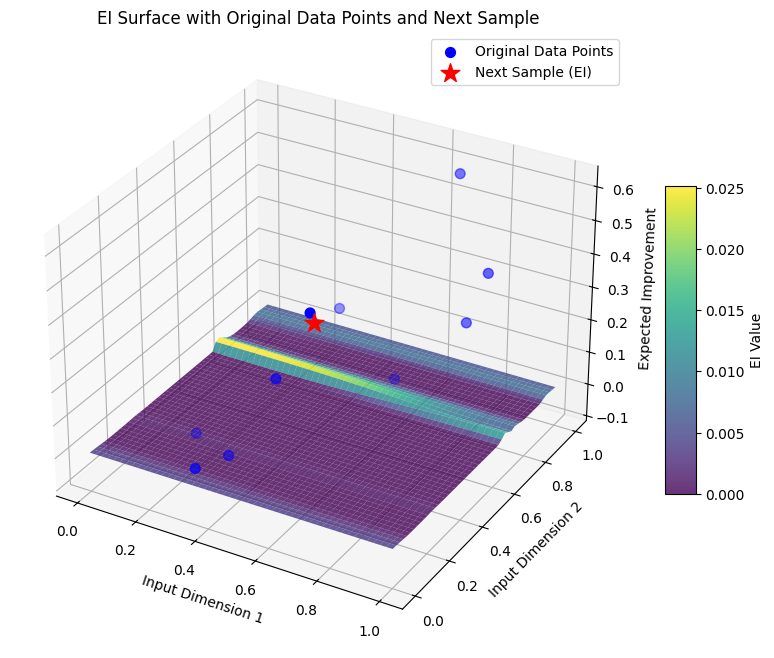

In [5]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# Example dataset: two input dimensions (X) and one output variable (y)
# Load the dataset provided
X = np.load("initial_inputs.npy")
y = np.load("initial_outputs.npy")

# Define the kernel for Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e2))

# Fit Gaussian Process model
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6, normalize_y=True)
gp.fit(X, y)

# Define the search space for the next sample (grid in [0,1]x[0,1])
grid_size = 50
x1 = np.linspace(0, 1, grid_size)
x2 = np.linspace(0, 1, grid_size)
X_grid = np.array([[a, b] for a in x1 for b in x2])

# Predict mean and standard deviation for each point in the grid
mean, std = gp.predict(X_grid, return_std=True)

# Expected Improvement (EI) acquisition function
best_y = np.max(y)  # For maximisation problem
xi = 0.01  # Small margin for improvement
z = (mean - best_y - xi) / std
ei = (mean - best_y - xi) * norm.cdf(z) + std * norm.pdf(z)

# Select the next input sample as the point with the highest EI
next_index = np.argmax(ei)
next_sample = X_grid[next_index]

# Reshape EI for plotting
EI_surface = ei.reshape(grid_size, grid_size)

# Create a 3D plot for EI surface
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

X1_mesh, X2_mesh = np.meshgrid(x1, x2)

# Plot the EI surface
surf = ax.plot_surface(X1_mesh, X2_mesh, EI_surface, cmap='viridis', alpha=0.8)

# Add original data points (blue circles)
ax.scatter(X[:, 0], X[:, 1], y, color='blue', marker='o', s=50, label='Original Data Points')

# Highlight the selected next point (red star)
ax.scatter(next_sample[0], next_sample[1], mean[next_index], color='red', marker='*', s=200, label='Next Sample (EI)')

# Add labels and title
ax.set_xlabel('Input Dimension 1')
ax.set_ylabel('Input Dimension 2')
ax.set_zlabel('Expected Improvement')
ax.set_title('EI Surface with Original Data Points and Next Sample')

# Add legend and colour bar
ax.legend()
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='EI Value')



# Week 1 Submission
0.693877-0.673469

---
---
## Week 2
Try to improve the process:
1. Build a SMBO (Sequential Model Based Optimisation) process to iteratively add new samples as they become available.
2. Visualize the performance - convergence
3. True to improve the various parameters!
4. Use Upper Confidence Bound to encourage exploration

Suggested new points: [[0.9650092713921214, 0.7540376184875043]]


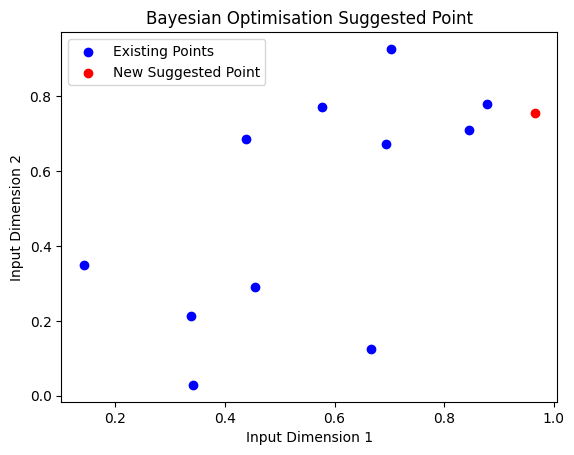

X: [0.6657995800131589, 0.12396912767534907], y: 0.5389961189269181
X: [0.8777909889953304, 0.7786275008473289], y: 0.42058623962798264
X: [0.14269907423594608, 0.34900513057320015], y: -0.06562362443733738
X: [0.8452754286767249, 0.7111202665952655], y: 0.293992912410866
X: [0.45464714105124415, 0.2904551797740609], y: 0.2149645101004509
X: [0.5777128444074784, 0.7719731841154063], y: 0.023105549798190586
X: [0.4381660616117107, 0.6850182567997548], y: 0.24461934400448035
X: [0.34174959302885033, 0.028697719822277867], y: 0.0387490151561584
X: [0.33864815688701766, 0.21386724563864368], y: -0.013857618149729824
X: [0.7026365569244406, 0.9265641975455574], y: 0.6112052157614438
X: [0.693877, 0.673469], y: 0.674355


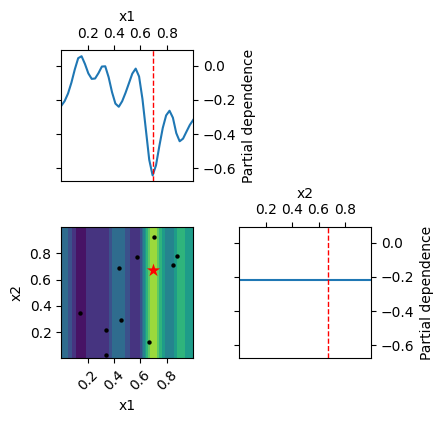

In [ ]:

from skopt import Optimizer
from skopt.plots import plot_objective
from skopt.space import Real
import matplotlib.pyplot as plt

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2')]

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator="GP", acq_func="EI", random_state=42)

# 3. Existing data (10 samples)
X = np.load("data/initial_inputs.npy").tolist()
y = np.load("data/initial_outputs.npy").tolist()

# insert a new observation at end of X and y (negate y for maximisation)
X.append([0.693877, 0.673469])
y.append(0.674355)

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_points = opt.ask(n_points=1)  # propose 3 new points
print("Suggested new points:", next_points)

# plot the scatter plot of existing points and the new suggested point
import matplotlib.pyplot as plt
existing_points = np.array(X)
new_point = np.array(next_points[0])
plt.scatter(existing_points[:, 0], existing_points[:, 1], c='blue', label='Existing Points')
plt.scatter(new_point[0], new_point[1], c='red', label='New Suggested Point')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Bayesian Optimisation Suggested Point')
plt.legend()
plt.show()

_ = plot_objective(res)





## Submission
0.965009-0.754037

---
---
# Week 3

Suggested new point: 0.686316-0.030316


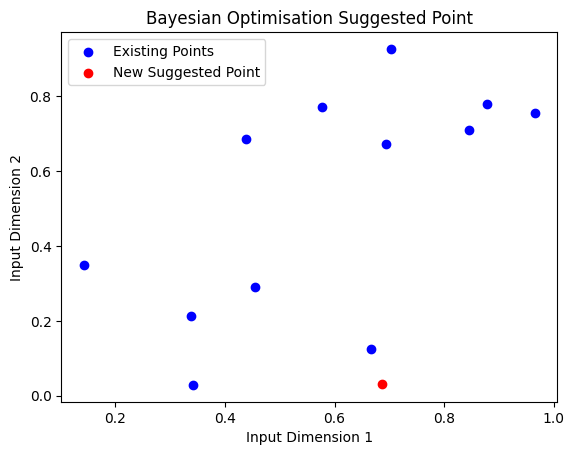

00. X: 0.665800, 0.123969, y:        0.538996
01. X: 0.877791, 0.778628, y:        0.420586
02. X: 0.142699, 0.349005, y:       -0.065624
03. X: 0.845275, 0.711120, y:        0.293993
04. X: 0.454647, 0.290455, y:        0.214965
05. X: 0.577713, 0.771973, y:        0.023106
06. X: 0.438166, 0.685018, y:        0.244619
07. X: 0.341750, 0.028698, y:        0.038749
08. X: 0.338648, 0.213867, y:       -0.013858
09. X: 0.702637, 0.926564, y:        0.611205
10. X: 0.693877, 0.673469, y:        0.674355
11. X: 0.965009, 0.754037, y:        0.054375


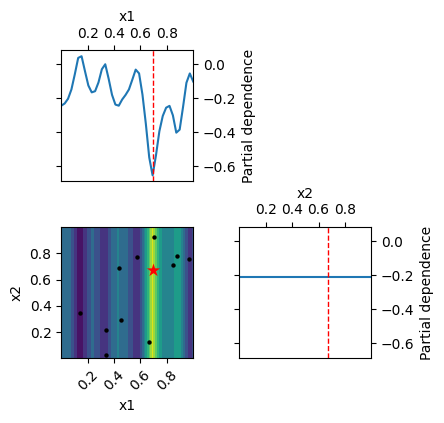

In [18]:

from skopt import Optimizer
from skopt.plots import plot_objective
from skopt.space import Real
import numpy as np

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2')]

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator="GP", acq_func="LCB", random_state=42, acq_func_kwargs={'kappa': 1.96})

# 3. Existing data (10 samples)
X = np.load("data/initial_inputs.npy").tolist()
y = np.load("data/initial_outputs.npy").tolist()

# insert a new observation at end of X and y (negate y for maximisation)
X.append([0.693877, 0.673469])
y.append(0.674355)

# insert second observation
X.append([0.965009, 0.754037])
y.append(0.054375)


# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_point = opt.ask(n_points=1)  # propose next point
print(f"Suggested new point: {next_point[0][0]:.6f}-{next_point[0][1]:.6f}")

# plot the scatter plot of existing points and the new suggested point
import matplotlib.pyplot as plt
existing_points = np.array(X)
new_point = np.array(next_point[0])
plt.scatter(existing_points[:, 0], existing_points[:, 1], c='blue', label='Existing Points')
plt.scatter(new_point[0], new_point[1], c='red', label='New Suggested Point')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Bayesian Optimisation Suggested Point')
plt.legend()
plt.show()

_ = plot_objective(res)

# negate all the y values back to original
y = [-val for val in y]

# Print X and y in a formatted way with unpacked coordinates
max_y_index = np.argmax(y)
# Use fixed width for y column (easier to read)
for i in range(len(X)):
    x_str = ", ".join(f"{val:.6f}" for val in X[i])
    
    # Right-align y values in 15 character width
    y_str = f"{y[i]:>15.6f}"
    
    if i == max_y_index:
        print(f"{i:02d}. \033[92mX: {x_str}, y: {y_str}\033[0m")
    else:
        print(f"{i:02d}. X: {x_str}, y: {y_str}")



---
---
## Week 4

Previous Sample: 0.686316-0.030316

Result: 0.5463952189956705

### Hyperparameter Choice
Some rapid convergenace then stable - balance exploration with exploitation here
- Acqusition Function - EI
- xi - 0.05


Suggested new point: 0.673848-1.000000


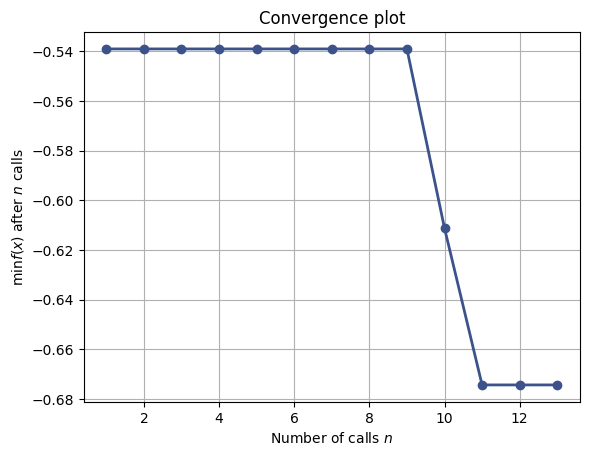

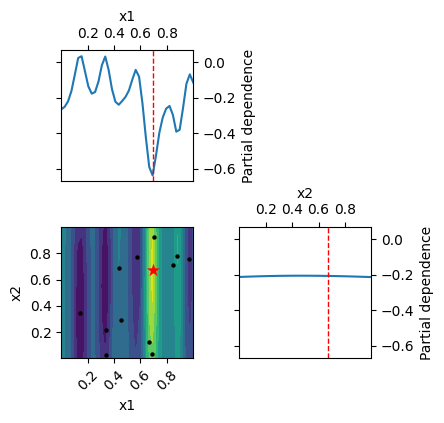

In [9]:
from skopt import Optimizer
from skopt.plots import plot_objective, plot_convergence
from skopt.space import Real
import numpy as np

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2')]

# set the hyperparameters for Optimizer
base_estimator = "GP"
acq_func = "EI"
random_state = 42
acq_func_kwargs = {'xi': 0.05}

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator=base_estimator, acq_func=acq_func, random_state=random_state, acq_func_kwargs=acq_func_kwargs)

# 3. Existing data (10 samples)
X = np.load("../data/f2/updated_inputs.npy").tolist()
y = np.load("../data/f2/updated_outputs.npy").tolist()

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_point = opt.ask(n_points=1)  # propose next point
print(f"Suggested new point: {next_point[0][0]:.6f}-{next_point[0][1]:.6f}")

# plot the convergence
__ = plot_convergence(res)

# plot the objective function
_ = plot_objective(res)




---
---
## Week 5

### Hyperparameter Choice - Last Week
Some rapid convergenace then stable - balance exploration with exploitation here
- Acqusition Function - EI
- xi - 0.05

### Observations - Not converging!!


Suggested new point: 0.743922-0.953033


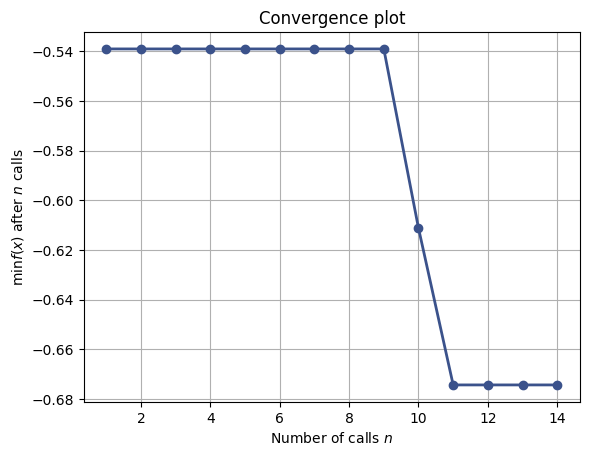

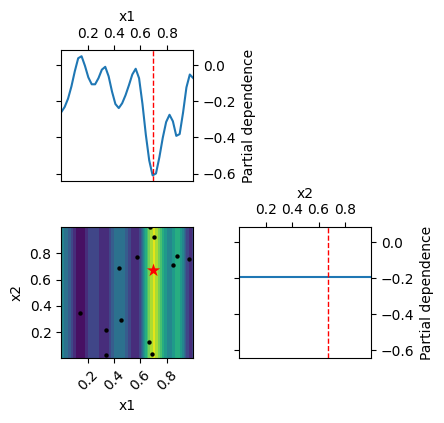

In [10]:
from skopt import Optimizer
from skopt.plots import plot_objective, plot_convergence
from skopt.space import Real
import numpy as np

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2')]

# set the hyperparameters for Optimizer
base_estimator = "GP"
acq_func = "EI"
random_state = 42
acq_func_kwargs = {'xi': 0.05}

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator=base_estimator, acq_func=acq_func, random_state=random_state, acq_func_kwargs=acq_func_kwargs)

# 3. Existing data (10 samples)
X = np.load("../data/f2/updated_inputs - Week 4.npy").tolist()
y = np.load("../data/f2/updated_outputs - Week 4.npy").tolist()

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_point = opt.ask(n_points=1)  # propose next point
print(f"Suggested new point: {next_point[0][0]:.6f}-{next_point[0][1]:.6f}")

# plot the convergence
__ = plot_convergence(res)

# plot the objective function
_ = plot_objective(res)


